**Quick EDA**

I will perform a quick EDA before doing anything else, it won't be long, because the dataset has only 2 values.

*Problem Formulation:*

The main problem of this task is to implement a model that is able to forecast whether an incident will occur in the next H-steps based on the last W-steps. I chose the NAB dataset because it includes datasets from AWS Cloudwatch which fit the role I'm applying to. 

In [25]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns


from src.feature_engineering import statistical_features as sf
from src.preprocessing import preprocessing as al


data_path=Path("./data/")
labels_path=Path("./data/labels/combined_windows.json")

with open(labels_path, 'r') as f:
    labels_dict = json.load(f)


    

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


I will use the following file for EDA and model learning. It was chosen based on the incidents number and the spikes in the "value" column. The dataset will be analyzed below.

In [26]:
name="realAWSCloudwatch/ec2_cpu_utilization_fe7f93.csv"

In [27]:
from statsmodels.graphics.tsaplots import plot_acf

def plot_feature_logic(df, file_name):
    fig, ax = plt.subplots(figsize=(12, 4))
    plot_acf(df['value'], lags=50, ax=ax)
    plt.title(f"Autocorrelation - Check which lags are important for {file_name}")
    plt.show()

In [28]:
def plot_eda_signal(df, file_name, timestamp_column:str,
                    value_column:str,
                    incident_column:str = 'is_incident'):
    plt.figure(figsize=(16, 6))
    plt.plot(df[timestamp_column], df[value_column], label='CPU Utilization', color='steelblue', alpha=0.8)
    plt.fill_between(df[timestamp_column], 0, df[value_column].max(), 
                     where=df[incident_column] == 1, 
                     color='red', alpha=0.3, label='Actual Incident')
    
    plt.title(f"EDA: Signal Analysis for {file_name}")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()
    plt.show()

In [29]:
def plot_class_balance(df, file_name, incident_column='is_incident'):

    counts = df[incident_column].value_counts().sort_index()
    
    plt.figure(figsize=(6, 4))

    ax = sns.barplot(x=counts.index, y=counts.values, palette='viridis')
    

    total = len(df)
    for p in ax.patches:
        height = p.get_height()
        percentage = f'{100 * height / total:.2f}%'
        ax.annotate(f'{int(height)}\n({percentage})', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.title(f"Class Balance: {file_name}")
    plt.xticks([0, 1], ['Normal (0)', 'Incident (1)'])
    plt.ylabel("Count")
    plt.ylim(0, max(counts.values) * 1.15)
    plt.show()

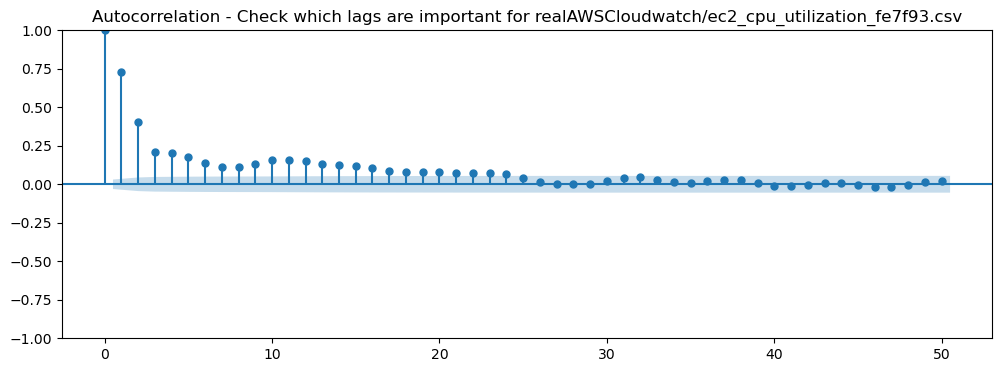

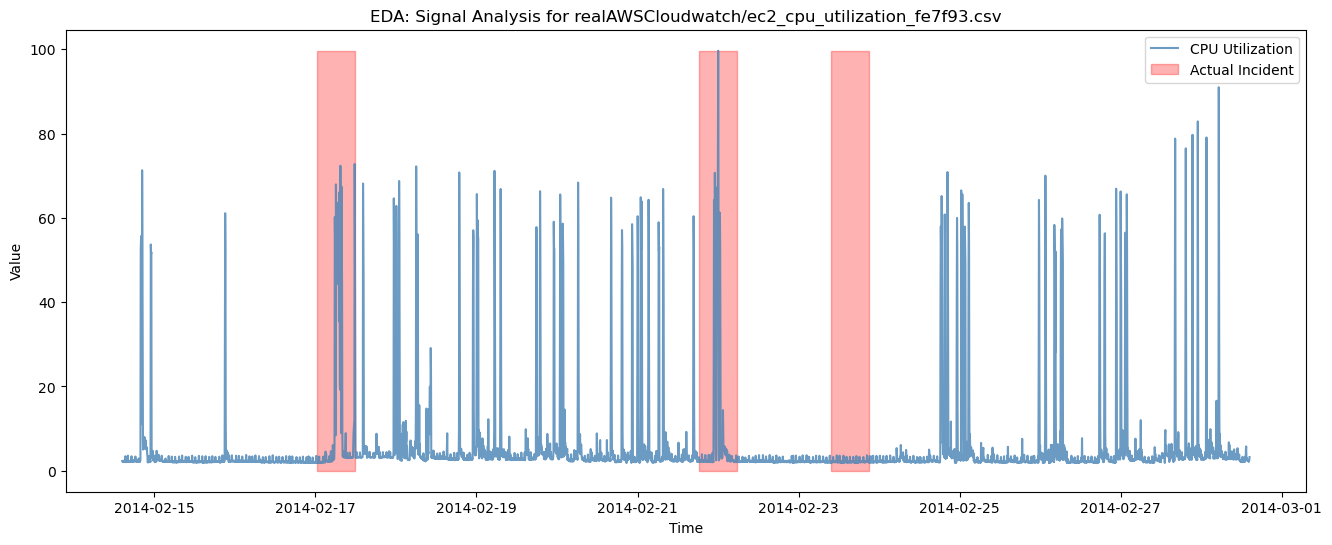

/tmp/nix-shell-10947-4186093254/ipykernel_20023/448866875.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette='viridis')


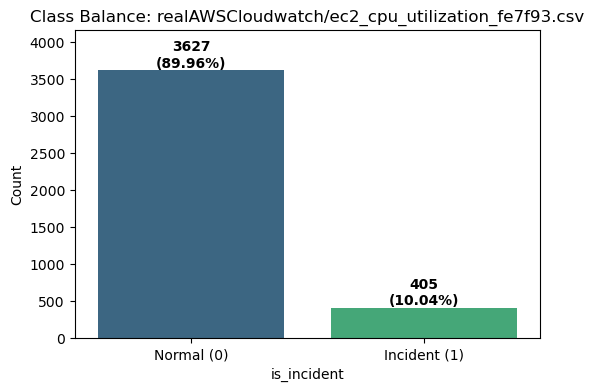

In [30]:

df=pd.read_csv(data_path / name , parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)
df = al.add_labels_function_json(name, labels_dict, "timestamp", df)
plot_feature_logic(df, name)
plot_eda_signal(df, name, "timestamp", "value","is_incident")
plot_class_balance(df, name, "is_incident")


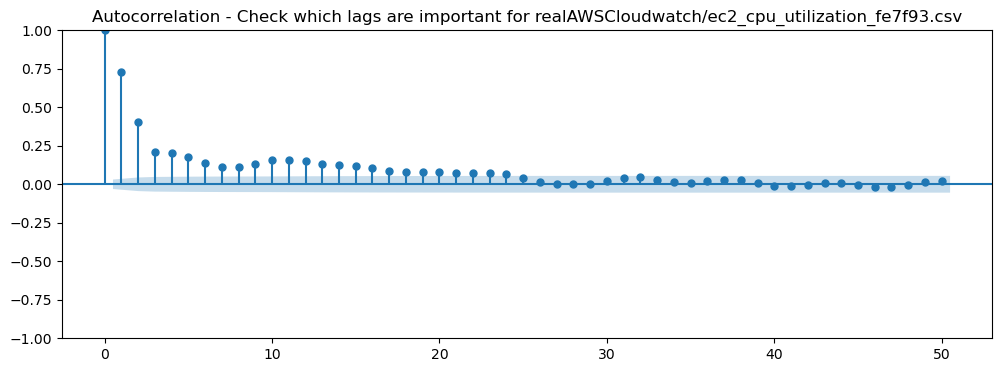

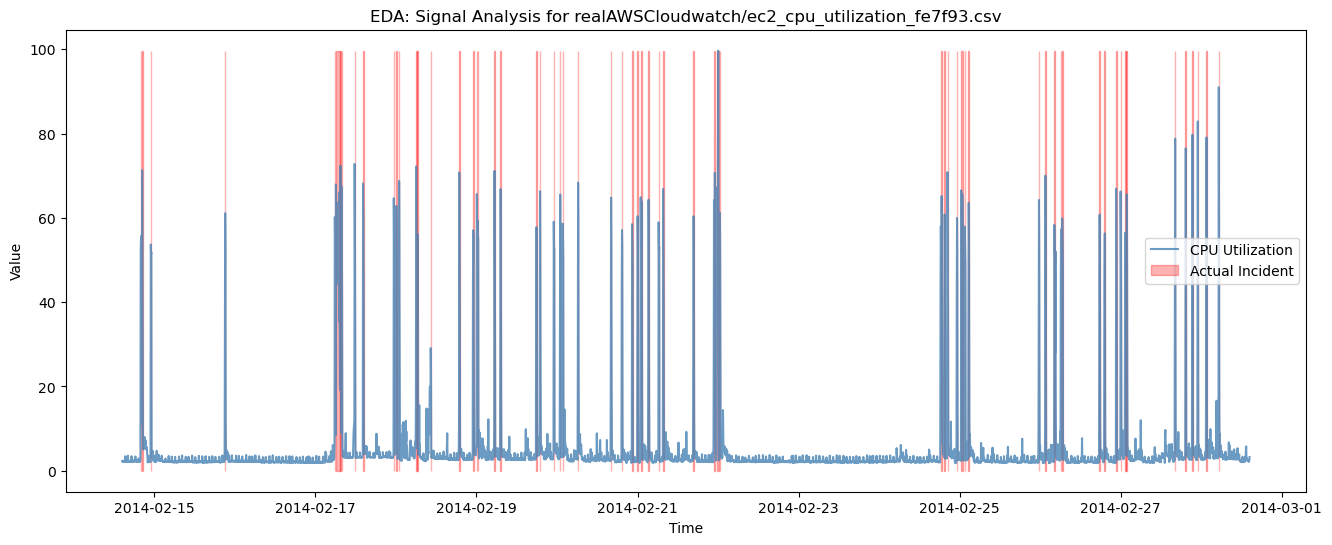

/tmp/nix-shell-10947-4186093254/ipykernel_20023/448866875.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette='viridis')


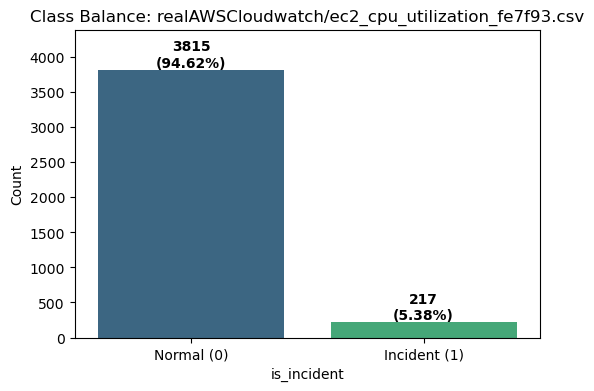

In [31]:

df1=pd.read_csv(data_path / name , parse_dates=["timestamp"])
df1 = df1.sort_values("timestamp").reset_index(drop=True)
df1 = al.add_labels_function(df1, threshold=25.0, value_column="value", target_column="is_incident")
plot_feature_logic(df1, name)
plot_eda_signal(df1, name, "timestamp", "value","is_incident")
plot_class_balance(df1, name, "is_incident")


As we can see from the graph 1,2,3 lags are the most important. A lag of 12 also seems useful. Lags will be made by add_labels_function in add_labels.py. About 90% of data is normal and only 10% are anomalies. 

For this prediction custom threshold will be used instead of using the given incidents labels. This decision was taken because the dataset is too small to precisely predict the anomalies. It can be also seen that the incidents marked by the dataset often start before the CPU usage spikes and are quite hard to predict.

The dataset will have different metrics added:
- Lags - Lags give the model the idea what was before the given number. They show differences and help the model see spikes or increase in value. They will be implemented depending on the W, if W<=10 lags will be added in range of 1-W. If W>10 lags with a value of 1,2,3 will be added, then the lag window will move by 5 and at the end W lag will be added
- Mean - Mean gives the model about the trends, a sliding window of W will be used to calculate it.
- Std - also gives the model information about the trends, a sliding window of W will be used to calculate it.

- The difference between current value and mean or std will be calculated to give the model idea between them. 

- Z-score anomaly detection method will also be calculated to show how much the data differs from the median
- Min, max, value range and different differences between values will be added to help the model predict the incidents

For this project i will use XGBoost model as it's a efficient and fast industry standard. The W will be 12 and the H will be 5.